In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch

from dvfm.data import sample_checkerboard, sample_moons, sample_spirals
from dvfm.flow_matching import sample
from dvfm.models import MLP
from dvfm.train import train_flow_matching

torch.manual_seed(0)
datasets = {
    "moons": sample_moons(50_000, seed=0),
    "spirals": sample_spirals(50_000, seed=0),
    "checkerboard": sample_checkerboard(50_000, seed=0),
}

models = {}
for name, data in datasets.items():
    print(f"--- {name} ---")
    models[name] = MLP()
    train_flow_matching(models[name], data, num_steps=5000)

--- moons ---
step     0 | loss 1.9288
step  1000 | loss 1.3755
step  2000 | loss 1.4140
step  3000 | loss 1.4454
step  4000 | loss 1.6130
--- spirals ---
step     0 | loss 1.8799
step  1000 | loss 1.4413
step  2000 | loss 1.4437
step  3000 | loss 1.4783
step  4000 | loss 1.5758
--- checkerboard ---
step     0 | loss 2.2934
step  1000 | loss 1.8202
step  2000 | loss 1.7190
step  3000 | loss 1.7119
step  4000 | loss 1.7101


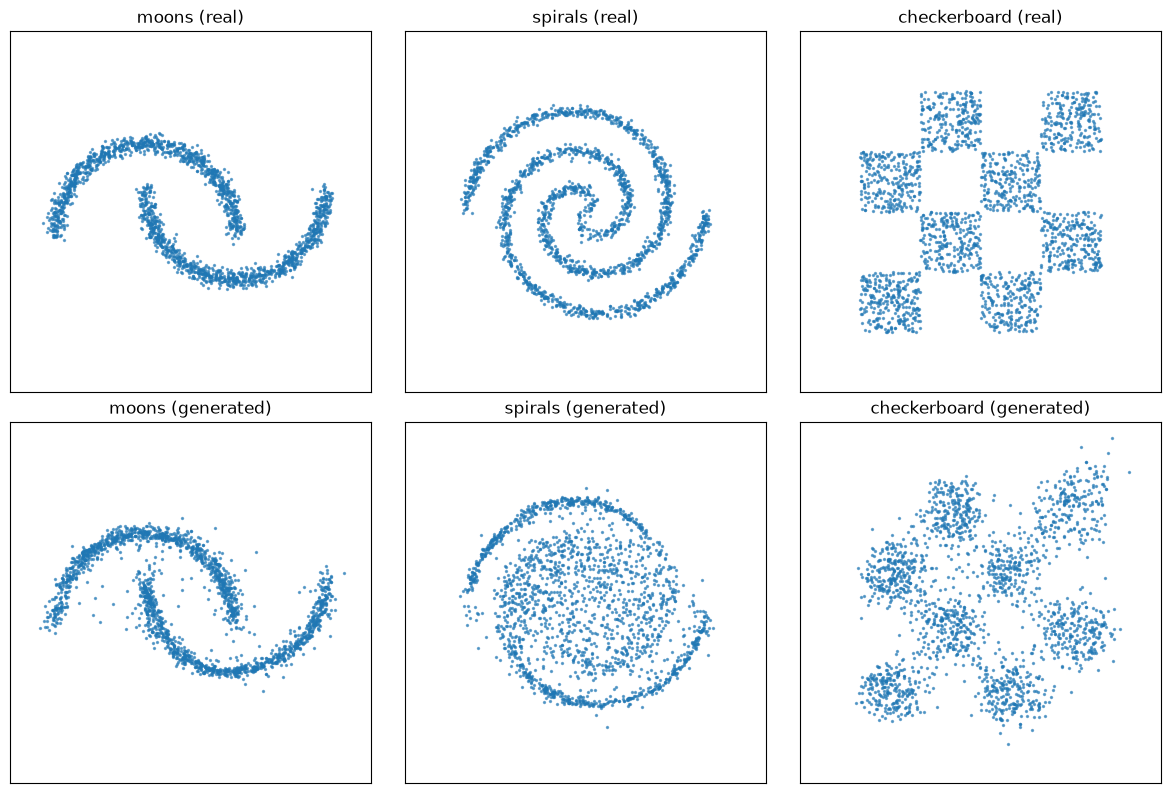

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for col, (name, data) in enumerate(datasets.items()):
    real = data[torch.randperm(len(data))[:2000]]
    torch.manual_seed(0)
    generated = sample(models[name], 2000, num_steps=100)

    for row, (points, label) in enumerate([(real, "real"), (generated, "generated")]):
        ax = axes[row, col]
        ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
        ax.set_title(f"{name} ({label})")
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [4]:
from dvfm.models import TimeEmbeddingMLP

new_models = {}
for name in ["spirals", "checkerboard"]:
    print(f"--- {name} (new model) ---")
    torch.manual_seed(0)
    new_models[name] = TimeEmbeddingMLP()
    train_flow_matching(new_models[name], datasets[name], num_steps=10_000, cosine_schedule=True)

--- spirals (new model) ---
step     0 | loss 2.0673
step  1000 | loss 1.5966
step  2000 | loss 1.5463
step  3000 | loss 1.4503
step  4000 | loss 1.6023
step  5000 | loss 1.4285
step  6000 | loss 1.4245
step  7000 | loss 1.4798
step  8000 | loss 1.4608
step  9000 | loss 1.4743
--- checkerboard (new model) ---
step     0 | loss 2.3940
step  1000 | loss 1.7490
step  2000 | loss 1.9358
step  3000 | loss 1.6460
step  4000 | loss 1.7072
step  5000 | loss 1.6117
step  6000 | loss 1.5805
step  7000 | loss 1.6464
step  8000 | loss 1.7582
step  9000 | loss 1.6081


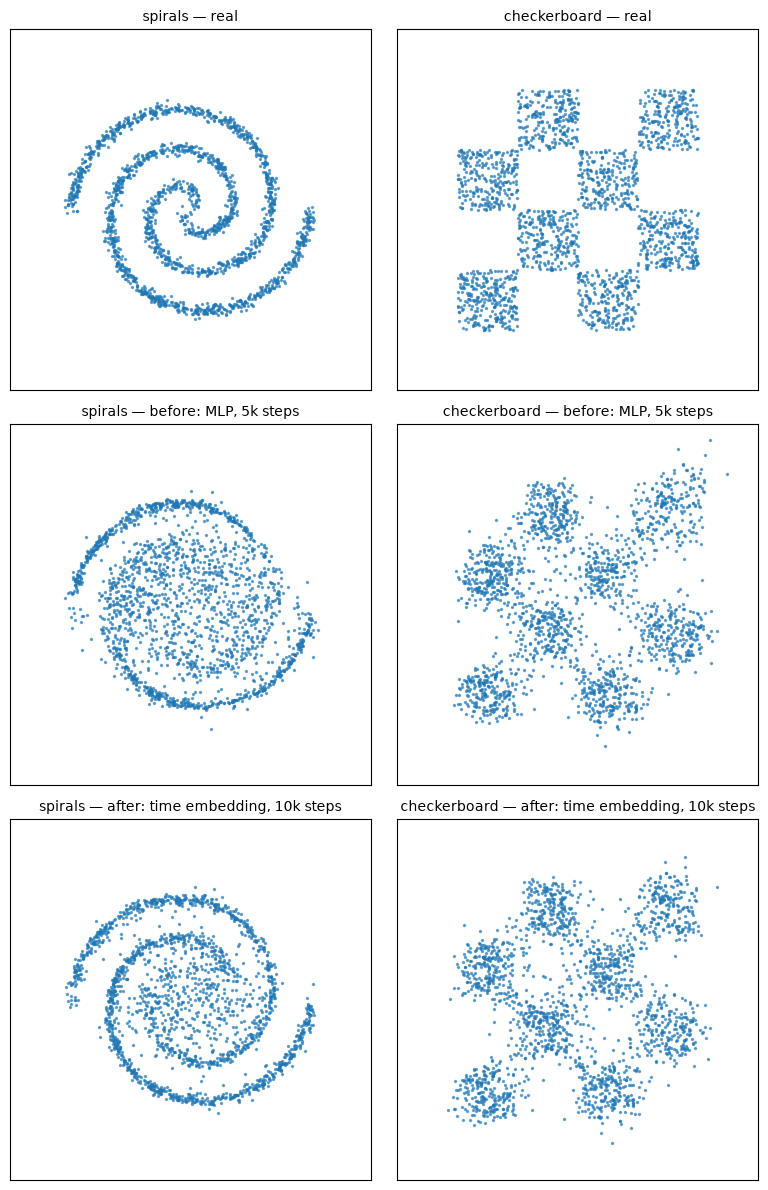

In [5]:
from pathlib import Path

rows = [("real", None), ("before: MLP, 5k steps", models), ("after: time embedding, 10k steps", new_models)]
names = ["spirals", "checkerboard"]

fig, axes = plt.subplots(len(rows), len(names), figsize=(8, 12))
for col, name in enumerate(names):
    for row, (label, model_dict) in enumerate(rows):
        if model_dict is None:
            points = datasets[name][torch.randperm(len(datasets[name]))[:2000]]
        else:
            torch.manual_seed(0)
            points = sample(model_dict[name], 2000, num_steps=100)
        ax = axes[row, col]
        ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
        ax.set_title(f"{name} — {label}", fontsize=10)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
Path("../assets").mkdir(exist_ok=True)
plt.savefig("../assets/fm_before_after.png", dpi=150, bbox_inches="tight")
plt.show()